In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
#%cd /content/drive/MyDrive

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1. Učitavanje podataka
# ----------------------------
# ISPRAVAK parsiranja minuta: minute tipa "1,641" zapisane su s tisućicom, pa je
# nužan thousands=",". Bez toga su takve vrijednosti postajale NaN i igrači s
# najviše odigranih minuta (prvotimci) tiho su ispadali iz uzorka.
df = pd.read_csv("igraci.csv", thousands=",")

# Pomoćna funkcija: robusna pretvorba u broj.
# (U CSV-u se javljaju vrijednosti tipa "01.04" ili "1,641" pa ih čistimo.)
def to_num(col):
    return pd.to_numeric(df[col].astype(str).str.replace(",", "", regex=False),
                         errors="coerce")

# ----------------------------
# 2. Filtriranje na DEFINIRANI UZORAK: top-5 europskih liga, polusezona 2025/26
# ----------------------------
# NAPOMENA: ovo NIJE ispravak greške u podacima, nego definicija uzorka rada.
# Promatramo pet najjačih europskih liga; igrači izvan njih (npr. iz HNL-a)
# prirodno ispadaju, kao i eventualni ponovljeni redci zaglavlja u CSV-u.
top5_ligas = ["eng Premier League", "es La Liga", "it Serie A",
              "de Bundesliga", "fr Ligue 1"]
df = df[df["Comp"].isin(top5_ligas)].reset_index(drop=True)

# Minimalna minutaža: per-90 vrijednosti su stabilnije uz dovoljan uzorak minuta.
df["Min"] = to_num("Min")
df = df[df["Min"] >= 450].reset_index(drop=True)

# ----------------------------
# 3. Izgradnja čistog, dosljedno PER-90 prostora značajki (9 značajki)
# ----------------------------
# Sve značajke mjere STIL igre (po 90 minuta), a ne obujam. Uklonjeni su:
#   - duplikati (ukupno vs per-90)  -> zadržana je per-90 razina,
#   - zbrojevi (G+A, npxG+xAG ...)  -> linearne kombinacije drugih značajki,
#   - penali (PK, PKatt)            -> šum za stil igre.
# Stvarna i očekivana strana simetrično su BEZ penala (G-PK i npxG).
# VAŽNO: u ovom CSV-u su PrgC/PrgP/PrgR/CrdY/CrdR već per-90 (provjereno na
# podacima), pa se uzimaju kako jesu — bez dijeljenja sa "90s".
feature_map = {
    "G-PK_90": "G-PK.1",   # ne-penalski golovi / 90
    "Ast_90":  "Ast.1",    # asistencije / 90
    "xAG_90":  "xAG.1",    # očekivane asistencije (xAG) / 90
    "npxG_90": "npxG.1",   # ne-penalski očekivani golovi (npxG) / 90
    "PrgC_90": "PrgC",     # progresivna vođenja lopte / 90
    "PrgP_90": "PrgP",     # progresivni dodavanja / 90
    "PrgR_90": "PrgR",     # progresivna primanja lopte / 90
    "CrdY_90": "CrdY",     # žuti kartoni / 90
    "CrdR_90": "CrdR",     # crveni kartoni / 90
}
for new_name, src in feature_map.items():
    df[new_name] = to_num(src)

feature_cols = list(feature_map.keys())

# ----------------------------
# 4. Metapodaci i nedostajuće vrijednosti
# ----------------------------
metadata_cols = ["Player", "Pos", "Squad", "Comp", "Nation", "Age"]
metadata_cols = [c for c in metadata_cols if c in df.columns]
df = df[metadata_cols + feature_cols].copy()
df[feature_cols] = df[feature_cols].fillna(0)

# ----------------------------
# 5. Standardizacija (z-score) PRIJE bilo kakvog računanja sličnosti
# ----------------------------
# Sve metrike sličnosti rade na ovim standardiziranim značajkama.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Konačni oblik skupa podataka:", df_scaled.shape)
print("Broj značajki:", len(feature_cols))
print("Značajke:", feature_cols)

Konačni oblik skupa podataka: (1278, 15)
Broj značajki: 9
Značajke: ['G-PK_90', 'Ast_90', 'xAG_90', 'npxG_90', 'PrgC_90', 'PrgP_90', 'PrgR_90', 'CrdY_90', 'CrdR_90']


In [4]:
# ----------------------------
# 2. Podjela igrača po skupinama pozicija
# ----------------------------
def get_position_group(pos):
    """
    Preslikava detaljne oznake pozicija u široke skupine pozicija.
    Rješava igrače s više pozicija uzimajući primarnu (prvu) poziciju.
    """
    if pd.isna(pos):
        return 'UNKNOWN'

    # Uzmi primarnu poziciju (prvu navedenu)
    primary_pos = pos.split(',')[0].strip()

    # Preslikavanje u glavne skupine
    if 'GK' in primary_pos:
        return 'GK'
    elif any(p in primary_pos for p in ['CB', 'LB', 'RB', 'WB', 'DF']):
        return 'DEF'
    elif any(p in primary_pos for p in ['DM', 'CM', 'AM', 'MF']):
        return 'MID'
    elif any(p in primary_pos for p in ['FW', 'LW', 'RW', 'ST', 'CF']):
        return 'FWD'
    else:
        # Rezervna opcija
        if 'DF' in pos or 'B' in primary_pos:
            return 'DEF'
        elif 'MF' in pos or 'M' in primary_pos:
            return 'MID'
        elif 'FW' in pos or 'W' in primary_pos:
            return 'FWD'
        return 'UNKNOWN'

# Primjena grupiranja pozicija
df_scaled['PosGroup'] = df_scaled['Pos'].apply(get_position_group)

# ----------------------------
# Isključivanje golmana (GK) iz cijele analize
# ----------------------------
# Skup značajki je čisto OFENZIVAN (golovi, xG, asistencije, progresije, kartoni).
# Za golmane su te značajke gotovo nula: unutar GK grupe čak 3 značajke
# (G-PK_90, PrgC_90, PrgR_90) imaju NULTU varijancu, pa korelacijska matrica M
# (za soft_cosine) nije valjana, a sličnost je degenerirana (prosj. kosinus ~0.91 —
# golmani su praktički neraspoznatljivi). Isključenjem GK opseg postaje dosljedan
# postojećem K-Means/t-SNE dijelu (FWD/MID/DEF). Golmani se u radu navode kao
# LIMITACIJA (nedostatak golmanskih značajki), ne kao greška.
df_scaled = df_scaled[df_scaled['PosGroup'] != 'GK'].reset_index(drop=True)

print("Distribucija grupa pozicija (bez golmana):")
print(df_scaled['PosGroup'].value_counts())

Distribucija grupa pozicija (bez golmana):
PosGroup
DEF    492
MID    441
FWD    310
Name: count, dtype: int64


In [5]:
import numpy as np
from sklearn.decomposition import PCA

# ----------------------------
# 3. Skupovi podataka po pozicijskim grupama
# ----------------------------
# Za SVAKU grupu čuvamo:
#   - 'std_features': standardizirane značajke (NA NJIMA se računaju SVE metrike),
#   - 'pca_features': PCA projekcija (koristi se ISKLJUČIVO za BASELINE: PCA + kosinus).
position_data = {}

all_pos_groups = df_scaled['PosGroup'].unique().tolist()
print(f"Pronađene skupine pozicija: {all_pos_groups}")

for pos_group in all_pos_groups:
    df_pos = df_scaled[df_scaled['PosGroup'] == pos_group].copy().reset_index(drop=True)

    if len(df_pos) == 0:
        print(f"Upozorenje: Nema pronađenih igrača za {pos_group}")
        continue

    # Standardizirane značajke za ovu grupu (pre-PCA) — temelj svih metrika.
    std_features = df_pos[feature_cols].values

    # PCA samo za baseline referencu (zadržavamo 95% varijance).
    pca = PCA(n_components=0.95, random_state=42)
    pca_features = pca.fit_transform(std_features)

    print(f"\n{pos_group}: {len(df_pos)} igrača, {len(feature_cols)} značajki "
          f"(baseline PCA: {pca.n_components_} komponenti)")

    position_data[pos_group] = {
        'df': df_pos,
        'features': feature_cols,
        'std_features': std_features,      # za cosine/euclidean/dot_product/soft_cosine
        'pca_features': pca_features,      # za baseline (PCA + kosinus)
        'n_features': len(feature_cols),
        'pca_components': pca.n_components_,
    }

print("\n" + "=" * 50)
print(f"Skupovi podataka po pozicijama stvoreni: {list(position_data.keys())}")
print(f"Ukupan broj igrača: {sum(len(d['df']) for d in position_data.values())}")

Pronađene skupine pozicija: ['FWD', 'MID', 'DEF']

FWD: 310 igrača, 9 značajki (baseline PCA: 8 komponenti)

MID: 441 igrača, 9 značajki (baseline PCA: 7 komponenti)

DEF: 492 igrača, 9 značajki (baseline PCA: 7 komponenti)

Skupovi podataka po pozicijama stvoreni: ['FWD', 'MID', 'DEF']
Ukupan broj igrača: 1243


In [6]:
# ----------------------------
# 4. BASELINE: kosinusna sličnost na PCA značajkama (referenca za usporedbu)
# ----------------------------
# Ovo je POLAZIŠNA metoda iz izvornog projekta (PCA + kosinus). Zadržavamo je
# odvojeno kao referentnu točku spram koje uspoređujemo četiri "čiste" metrike
# (koje rade na standardiziranim značajkama, bez PCA).
from sklearn.metrics.pairwise import cosine_similarity

for pos_group, data in position_data.items():
    data['baseline_similarity'] = cosine_similarity(data['pca_features'])
    print(f"{pos_group}: baseline matrica sličnosti {data['baseline_similarity'].shape} "
          f"(PCA + kosinus)")

FWD: baseline matrica sličnosti (310, 310) (PCA + kosinus)
MID: baseline matrica sličnosti (441, 441) (PCA + kosinus)
DEF: baseline matrica sličnosti (492, 492) (PCA + kosinus)


## Faza 2: Metrike sličnosti

U ovom dijelu definiramo **četiri metrike sličnosti** koje ćemo međusobno usporediti.
Za razliku od baseline pristupa (PCA + kosinus), sve četiri metrike rade izravno na
**standardiziranim značajkama prije PCA**, i to **unutar pozicijske grupe** svakog igrača:

1. **`cosine`** — kosinusna sličnost; mjeri sličnost *smjera* profila (stil), neovisno o magnitudi.
2. **`euclidean`** — euklidska *udaljenost*; manja vrijednost znači sličnijeg igrača (rangira se uzlazno).
3. **`dot_product`** — nenormalizirani skalarni produkt; uz smjer nagrađuje i *intenzitet* značajki.
4. **`soft_cosine`** — soft-kosinus s matricom sličnosti značajki **M** (Pearsonova korelacija
   značajki, računata unutar svake pozicijske grupe); dopušta da povezane značajke doprinose zajednički.

Funkcija `find_similar_players(player_name, metric=...)` jedinstveno opslužuje sve metrike i
zadržava postojeće filtre (dob, klub, liga).

In [7]:
# ----------------------------
# 5. Metrike sličnosti (čiste funkcije)
# ----------------------------
# Sve metrike rade na STANDARDIZIRANIM značajkama (pre-PCA), unutar pozicijske grupe.
# Konvencija: funkcija prima matricu X (redak = igrač) i indeks ciljnog igrača te
# vraća vektor rezultata prema SVIM igračima u grupi.
#   - cosine, dot_product, soft_cosine -> VEĆE = sličnije (rangiranje silazno)
#   - euclidean                        -> MANJE = sličnije (rangiranje uzlazno)

def cosine(X, idx):
    """Kosinusna sličnost ciljnog retka `idx` prema svim retcima matrice X.

    Mjeri sličnost SMJERA vektora (profil/stil igre), neovisno o magnitudi.
    Veće = sličnije.
    """
    target = X[idx]
    norms = np.linalg.norm(X, axis=1) * np.linalg.norm(target)
    norms[norms == 0] = 1e-12
    return (X @ target) / norms


def euclidean(X, idx):
    """Euklidska udaljenost ciljnog retka `idx` prema svim retcima matrice X.

    Mjeri apsolutnu razliku u standardiziranom prostoru značajki (i smjer i intenzitet).
    MANJE = sličnije -> pri rangiranju se sortira UZLAZNO.
    """
    diff = X - X[idx]
    return np.sqrt(np.sum(diff ** 2, axis=1))


def dot_product(X, idx):
    """Nenormalizirani skalarni produkt ciljnog retka `idx` prema svim retcima.

    Za razliku od kosinusa NE poništava magnitudu, pa nagrađuje igrače koji su
    izraženi (visoke vrijednosti) u istim značajkama kao i cilj. Veće = sličnije.
    """
    return X @ X[idx]


def soft_cosine(X, idx, M):
    """Soft-kosinusna sličnost ciljnog retka `idx` prema svim retcima.

        sim(a, b) = (aᵀ M b) / ( sqrt(aᵀ M a) · sqrt(bᵀ M b) )

    Klasični kosinus implicitno pretpostavlja da su značajke međusobno ORTOGONALNE
    (M = I). Soft-kosinus tu pretpostavku opušta uvođenjem matrice sličnosti
    ZNAČAJKI M (d×d): povezane značajke tada doprinose zajednički.

    Zašto M = korelacijska matrica značajki:
      Za M uzimamo Pearsonovu korelacijsku matricu standardiziranih značajki,
      računatu UNUTAR svake pozicijske grupe. Značajke koje mjere srodan aspekt
      igre (npr. npxG_90 i G-PK_90, ili PrgC_90 i PrgR_90) jako su korelirane, pa
      ih soft-kosinus tretira kao djelomično ISTU dimenziju umjesto kao neovisne
      osi — čime ublažava preklapanje informacija među značajkama. Korelacijska
      matrica je k tome pozitivno semidefinitna (Gramova matrica standardiziranih
      značajki), pa je gornja formula valjan (semi-)unutarnji produkt i izraz je
      dobro definiran. Veće = sličnije.
    """
    target = X[idx]
    Mb = M @ target
    num = X @ Mb                                    # aᵀ M b za svaki redak a
    aMa = np.einsum('ij,jk,ik->i', X, M, X)         # aᵀ M a za svaki redak a
    bMb = float(target @ Mb)                        # bᵀ M b (skalar)
    denom = np.sqrt(np.clip(aMa, 1e-12, None)) * np.sqrt(max(bMb, 1e-12))
    return num / denom


# Registar metrika: ime -> specifikacija (funkcija, treba li M, smjer rangiranja).
METRICS = {
    'cosine':      {'fn': cosine,      'needs_M': False, 'ascending': False},
    'euclidean':   {'fn': euclidean,   'needs_M': False, 'ascending': True},
    'dot_product': {'fn': dot_product, 'needs_M': False, 'ascending': False},
    'soft_cosine': {'fn': soft_cosine, 'needs_M': True,  'ascending': False},
}

# ----------------------------
# 6. Matrica sličnosti značajki M za soft-kosinus (Pearson, UNUTAR svake grupe)
# ----------------------------
for pos_group, data in position_data.items():
    # rowvar=False -> korelacija MEĐU stupcima (značajkama), ne među igračima.
    M = np.corrcoef(data['std_features'], rowvar=False)
    M = np.nan_to_num(M, nan=0.0)   # zaštita ako bi neka značajka imala nultu varijancu
    data['M'] = M

print("Metrike spremne:", list(METRICS.keys()))
print("Matrica M (soft_cosine) izračunata po grupama; oblik za FWD:",
      position_data['FWD']['M'].shape)

Metrike spremne: ['cosine', 'euclidean', 'dot_product', 'soft_cosine']
Matrica M (soft_cosine) izračunata po grupama; oblik za FWD: (9, 9)


In [8]:
# ----------------------------
# 7. Pronalaženje sličnih igrača (jedinstvena funkcija za sve metrike)
# ----------------------------

def find_similar_players(player_name, metric='cosine', n_similar=10,
                         age_range=None, exclude_same_team=False,
                         exclude_same_league=False, verbose=True):
    """Pronađi najsličnije igrače zadanom igraču prema odabranoj metrici.

    Parametri
    ---------
    player_name : str
        Ime (ili dio imena) ciljnog igrača.
    metric : {'cosine', 'euclidean', 'dot_product', 'soft_cosine'}
        Metrika sličnosti. SVE rade na standardiziranim značajkama (pre-PCA),
        unutar pozicijske grupe ciljnog igrača.
    n_similar : int
        Koliko najsličnijih igrača vratiti.
    age_range : (min_age, max_age) ili None
        Filtar po dobi (godine iz stupca Age).
    exclude_same_team : bool
        Izbaci igrače iz istog kluba kao cilj.
    exclude_same_league : bool
        Izbaci igrače iz iste lige kao cilj.
    verbose : bool
        Ispiši informacije o ciljnom igraču i metrici.

    Vraća
    -----
    pandas.DataFrame
        Top-n sličnih igrača sa stupcem 'Score'. Za 'euclidean' je 'Score'
        udaljenost (manje = sličnije); za ostale metrike veće = sličnije.
    """
    if metric not in METRICS:
        raise ValueError(f"Nepoznata metrika '{metric}'. "
                         f"Dostupne: {list(METRICS.keys())}")
    if not position_data:
        print("Greška: position_data je prazan. Prvo pokrenite prethodne ćelije.")
        return None

    # --- pronalazak ciljnog igrača kroz sve pozicijske grupe ---
    target_pos_group = target_idx = target_info = None
    for pos_group, data in position_data.items():
        df_pos = data['df']
        matches = df_pos[df_pos['Player'].str.contains(player_name, case=False, na=False)]
        if len(matches) > 0:
            if len(matches) > 1 and verbose:
                print(f"Pronađeno više podudaranja za '{player_name}':")
                print(matches[['Player', 'Squad', 'Pos']].to_string())
                print("Koristi se prvo podudaranje.\n")
            target_pos_group = pos_group
            target_idx = matches.index[0]
            target_info = matches.iloc[0]
            break

    if target_pos_group is None:
        print(f"Igrač '{player_name}' nije pronađen u skupu podataka.")
        return None

    data = position_data[target_pos_group]
    df_pos = data['df']
    X = data['std_features']            # standardizirane značajke (pre-PCA)

    if verbose:
        print(f"Cilj: {target_info['Player']} | Pozicija: {target_info['Pos']} "
              f"(Grupa: {target_pos_group}) | Klub: {target_info['Squad']}")
        if 'Comp' in target_info.index:
            print(f"Liga: {target_info['Comp']} | Dob: {target_info.get('Age', 'n/a')}")
        print(f"Metrika: {metric}")
        print("-" * 60)

    # --- izračun rezultata prema odabranoj metrici ---
    spec = METRICS[metric]
    if spec['needs_M']:
        scores = spec['fn'](X, target_idx, data['M'])
    else:
        scores = spec['fn'](X, target_idx)

    results = df_pos.copy()
    results['Score'] = scores
    results = results[results.index != target_idx]   # makni samog ciljnog igrača

    # --- filtri (isti kao u izvornoj verziji) ---
    if exclude_same_team:
        results = results[results['Squad'] != target_info['Squad']]
    if exclude_same_league and 'Comp' in results.columns:
        results = results[results['Comp'] != target_info['Comp']]
    if age_range is not None and 'Age' in results.columns:
        min_age, max_age = age_range
        def extract_age(x):
            try:
                return int(str(x).split('-')[0])
            except (ValueError, TypeError):
                return None
        ages = results['Age'].apply(extract_age)
        results = results[ages.notna() & (ages >= min_age) & (ages <= max_age)]

    # --- rangiranje: uzlazno za euklidsku udaljenost, inače silazno ---
    results = results.sort_values('Score', ascending=spec['ascending'])
    top = results.head(n_similar)

    out_cols = ['Player', 'Squad', 'Pos']
    if 'Comp' in top.columns:
        out_cols.append('Comp')
    if 'Age' in top.columns:
        out_cols.append('Age')
    out_cols.append('Score')
    return top[out_cols].reset_index(drop=True)


def list_all_players(pos_group=None):
    """Popis svih igrača u skupu (opcionalno samo jedne pozicijske grupe)."""
    if pos_group and pos_group in position_data:
        return position_data[pos_group]['df'][['Player', 'Squad', 'Pos']].reset_index(drop=True)
    frames = []
    for pg, data in position_data.items():
        f = data['df'][['Player', 'Squad', 'Pos']].copy()
        f['PosGroup'] = pg
        frames.append(f)
    return pd.concat(frames, ignore_index=True)


print("Funkcije spremne. find_similar_players(metric=...) podržava:",
      list(METRICS.keys()))

Funkcije spremne. find_similar_players(metric=...) podržava: ['cosine', 'euclidean', 'dot_product', 'soft_cosine']


In [9]:
# ----------------------------
# 8. Demo: ista meta, sve četiri metrike
# ----------------------------
# Prikaz kako se top-lista mijenja ovisno o odabranoj metrici (za istog igrača).
demo_player = "Haaland"
print(f"Demo — najsličniji igrači za '{demo_player}' po svakoj metrici:")
for i, met in enumerate(METRICS):
    # informacije o ciljnom igraču ispisujemo samo jednom (prvi prolaz)
    result = find_similar_players(demo_player, metric=met, n_similar=5,
                                  verbose=(i == 0))
    print(f"\n--- Metrika: {met} ---")
    if result is not None:
        print(result.to_string(index=False))

# ----------------------------
# Demo: korištenje filtera (dob, ista liga)
# ----------------------------
# Tražimo veznjake slične Phil Fodenu, ograničeno na dob 21–27 i izvan njegove lige.
print("\n" + "=" * 60)
print("Primjer s filtrima: soft_cosine, dob 21–27, izvan iste lige\n")
result = find_similar_players("Foden", metric="soft_cosine", n_similar=5,
                              age_range=(21, 27), exclude_same_league=True,
                              verbose=True)
if result is not None:
    print(result.to_string(index=False))

Demo — najsličniji igrači za 'Haaland' po svakoj metrici:
Cilj: Erling Haaland | Pozicija: FW (Grupa: FWD) | Klub: Manchester City
Liga: eng Premier League | Dob: 25-166
Metrika: cosine
------------------------------------------------------------

--- Metrika: cosine ---
            Player       Squad Pos               Comp    Age    Score
Robert Lewandowski   Barcelona  FW         es La Liga 37-135 0.977009
    Esteban Lepaul      Rennes  FW         fr Ligue 1 25-260 0.966355
     Donyell Malen Aston Villa  FW eng Premier League 26-359 0.966245
   Odsonne Édouard        Lens  FW         fr Ligue 1 27-352 0.962234
     Ferrán Torres   Barcelona  FW         es La Liga 25-308 0.961993

--- Metrika: euclidean ---
            Player          Squad   Pos          Comp    Age    Score
Robert Lewandowski      Barcelona    FW    es La Liga 37-135 1.883687
     Ferrán Torres      Barcelona    FW    es La Liga 25-308 2.285088
        Harry Kane  Bayern Munich FW,MF de Bundesliga 32-159 2.493739


In [10]:
# ----------------------------
# 11. K-Means klasteriranje - funkcija
# ----------------------------
from sklearn.cluster import KMeans

def perform_kmeans_clustering(df, feature_cols, n_clusters):
    """
    Primjenjuje K-Means klasteriranje na DataFrame na temelju navedenih značajki.

    Args:
        df (pd.DataFrame): Ulazni DataFrame.
        feature_cols (list): Popis naziva stupaca koji će se koristiti kao značajke za klasteriranje.
        n_clusters (int): Željeni broj klastera.

    Returns:
        pd.DataFrame: DataFrame s dodanim stupcem 'Cluster' koji sadrži oznake klastera.
    """
    print(f"Izvođenje K-Means klasteriranja s {n_clusters} klastera...")
    # Inicijalizacija KMeans modela
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

    # Prilagodba modela navedenim značajkama i dodijela oznaka klasterima
    df['Cluster'] = kmeans.fit_predict(df[feature_cols])

    print("\nBroj igrača po klasteru:")
    print(df['Cluster'].value_counts().sort_index())
    print("\nKlasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.")

    return df

In [11]:
print("Primjena K-Means klasteriranja na navedene grupe pozicija...")

# 12. Primjena K-Means klasteriranja
n_clusters_map = {
    'FWD': 4,
    'MID': 4,
    'DEF': 3
}

# 2. Iteracija kroz position_data rječnik za navedene grupe
for pos_group, n_clusters in n_clusters_map.items():
    if pos_group in position_data:
        print(f"\n--- Klasteriranje za {pos_group} (n_clusters={n_clusters}) ---")
        # a. Dohvaćanje DataFrame za trenutnu pos_group
        df_to_cluster = position_data[pos_group]['df'].copy()
        # b. Dohvaćanje feature_cols za trenutnu pos_group
        # Napomena: feature_cols je već globalno definiran i ovdje je konzistentan među grupama.
        # Ako su potrebne specifične značajke po grupi, to bi bilo `position_data[pos_group]['features']`.
        current_feature_cols = feature_cols

        # d. Pozov funkcije perform_kmeans_clustering
        clustered_df = perform_kmeans_clustering(df_to_cluster, current_feature_cols, n_clusters)

        # e. Ažuriranje DataFrame unutar position_data
        position_data[pos_group]['df'] = clustered_df
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena u position_data. Preskače se.")

print("\nK-Means klasteriranje primijenjeno na FWD, MID i DEF grupe. Stupac 'Cluster' dodan u njihove DataFrames.")

Primjena K-Means klasteriranja na navedene grupe pozicija...

--- Klasteriranje za FWD (n_clusters=4) ---
Izvođenje K-Means klasteriranja s 4 klastera...

Broj igrača po klasteru:
Cluster
0    145
1     70
2     36
3     59
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

--- Klasteriranje za MID (n_clusters=4) ---
Izvođenje K-Means klasteriranja s 4 klastera...

Broj igrača po klasteru:
Cluster
0    114
1    210
2     79
3     38
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

--- Klasteriranje za DEF (n_clusters=3) ---
Izvođenje K-Means klasteriranja s 3 klastera...

Broj igrača po klasteru:
Cluster
0    280
1    159
2     53
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

K-Means klasteriranje primijenjeno na FWD, MID i DEF grupe. Stupac 'Cluster' dodan u njihove DataFrames.


Vizualizacija distribucije igrača po klasterima...


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_13168\2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_13168\2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_13168\2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='vi

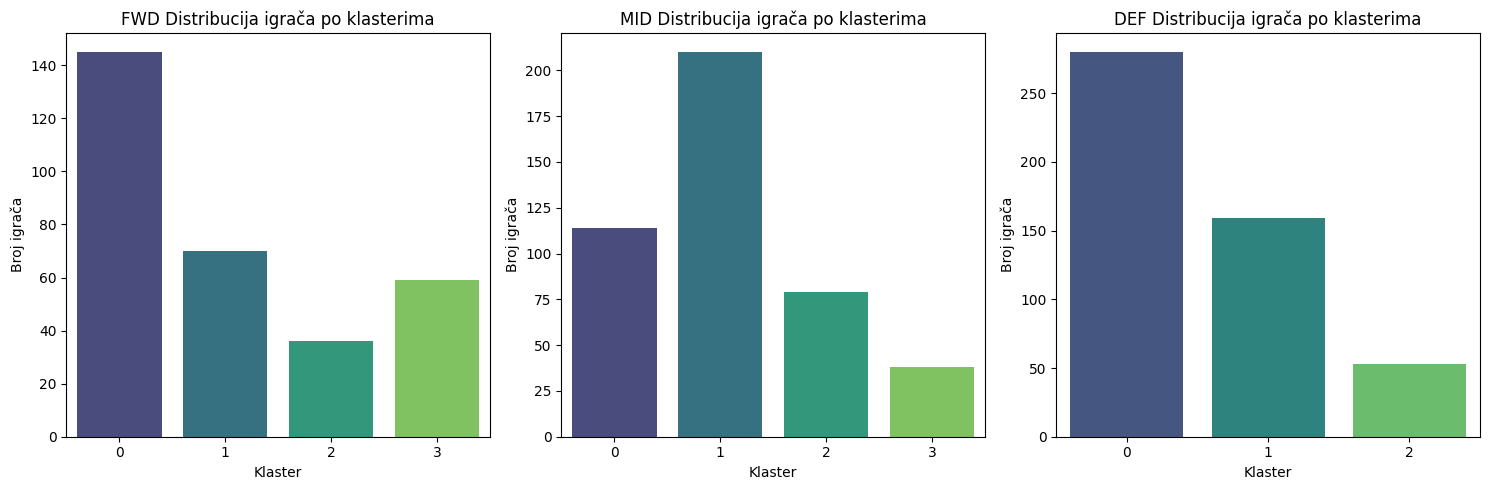

Vizualizacija distribucije igrača završena.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Vizualizacija distribucije igrača po klasterima...")

# ----------------------------
# 14. Vizualizacija distribucije klastera
# ----------------------------
# Definiranje grupe pozicija koje su klasterirane
clustered_pos_groups = ['FWD', 'MID', 'DEF']

plt.figure(figsize=(15, 5))

for i, pos_group in enumerate(clustered_pos_groups):
    if pos_group in position_data:
        df_clustered = position_data[pos_group]['df']

        # Broji igrače po klasteru
        cluster_counts = df_clustered['Cluster'].value_counts().sort_index()

        plt.subplot(1, len(clustered_pos_groups), i + 1)
        sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
        plt.title(f'{pos_group} Distribucija igrača po klasterima')
        plt.xlabel('Klaster')
        plt.ylabel('Broj igrača')
        plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Vizualizacija distribucije igrača završena.")

In [13]:
import random

# 15. Uzorkovanje igrača po klasterima
sample_players_to_highlight = {}

# 2. Definiranje popisa grupa pozicija za iteraciju
clustered_pos_groups_for_sampling = ['FWD', 'MID', 'DEF']

print("Uzorkovanje igrača iz svakog klastera za FWD, MID, DEF grupe...")

for pos_group in clustered_pos_groups_for_sampling:
    if pos_group in position_data:
        print(f"\n--- Uzorkovanje za {pos_group} ---")
        df_clustered = position_data[pos_group]['df']

        # 3. Iteracija kroz njegove jedinstvene ID-ove klastera
        unique_clusters = sorted(df_clustered['Cluster'].unique())

        sample_players_to_highlight[pos_group] = []

        for cluster_id in unique_clusters:
            print(f"  Klaster {cluster_id}:")
            # 4. Filtriranje DataFrame za igrače u ovom klasteru
            df_cluster = df_clustered[df_clustered['Cluster'] == cluster_id]

            # 5. Slučajno uzorkovanje do 5 igrača
            n_to_sample = min(len(df_cluster), 2)
            if n_to_sample > 0:
                # Odabir relevantnih stupaca za isticanje i pohrana
                sampled_players = df_cluster.sample(n=n_to_sample, random_state=42)[['Player', 'Squad', 'Pos', 'Cluster']].to_dict(orient='records')
                sample_players_to_highlight[pos_group].extend(sampled_players)

                # 7. Ispis imena odabranih igrača
                for player_info in sampled_players:
                    print(f"    - {player_info['Player']} ({player_info['Squad']}, {player_info['Pos']})")
            else:
                print("    (Nema igrača u ovom klasteru za uzorkovanje)")
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena ili nije klasterirana. Preskače se uzorkovanje.")

print("\nUzorkovanje igrača završeno. Uzorkovani igrači pohranjeni u 'sample_players_to_highlight'.")

Uzorkovanje igrača iz svakog klastera za FWD, MID, DEF grupe...

--- Uzorkovanje za FWD ---
  Klaster 0:
    - Ferran Jutglà (Celta Vigo, FW,MF)
    - Santiago Pierotti (Lecce, FW,MF)
  Klaster 1:
    - Antoine Griezmann (Atlético Madrid, FW,MF)
    - Erling Haaland (Manchester City, FW)
  Klaster 2:
    - Jesus Rodríguez (Como, FW)
    - Marius Bülter (Köln, FW)
  Klaster 3:
    - Antoine Semenyo (Bournemouth, FW,MF)
    - Pedro Neto (Chelsea, FW)

--- Uzorkovanje za MID ---
  Klaster 0:
    - Maxence Caqueret (Como, MF,FW)
    - Gauthier Hein (Metz, MF)
  Klaster 1:
    - Morten Thorsby (Genoa, MF)
    - Samir El Mourabet (Strasbourg, MF)
  Klaster 2:
    - Marcus Tavernier (Bournemouth, MF,FW)
    - Phil Foden (Manchester City, MF)
  Klaster 3:
    - Louis Mouton (Angers, MF)
    - Unai Vencedor Paris (Levante, MF)

--- Uzorkovanje za DEF ---
  Klaster 0:
    - Ousmane Camara (Angers, DF)
    - Matteo Bianchetti (Cremonese, DF)
  Klaster 1:
    - Cristiano Biraghi (Torino, DF,MF)
  

In [14]:
from sklearn.manifold import TSNE

print("Primjena t-SNE redukcije dimenzionalnosti na značajke FWD, MID i DEF...")

# ----------------------------
# 16. t-SNE redukcija dimenzionalnosti
# ----------------------------
# Definiranje grupe pozicija za primjenu t-SNE
tsne_pos_groups = ['FWD', 'MID', 'DEF']

for pos_group in tsne_pos_groups:
    if pos_group in position_data:
        print(f"\n--- Primjena t-SNE za {pos_group} ---")
        # Dohvaćanje PCA značajke za trenutnu grupu pozicija
        pca_features = position_data[pos_group]['pca_features']

        # Inicijalizacija t-SNE model
        # n_components=2 za 2D vizualizaciju
        # random_state za ponovljivost
        # perplexity je ključni parametar, često se podešava. Zadana vrijednost je 30.
        # n_iter je broj iteracija. Zadana vrijednost je 1000.
        tsne = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)

        # Prilagodba i transformacija pca značajke u 2D
        tsne_results = tsne.fit_transform(pca_features)

        # Dodavanje t-SNE rezultata u position_data rječnik
        position_data[pos_group]['tsne_2d'] = tsne_results
        print(f"t-SNE redukcija dimenzionalnosti završena za {pos_group}. Oblik: {tsne_results.shape}")
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena u position_data. Preskače se t-SNE.")

print("\nt-SNE redukcija dimenzionalnosti primijenjena na navedene grupe pozicija.")

Primjena t-SNE redukcije dimenzionalnosti na značajke FWD, MID i DEF...

--- Primjena t-SNE za FWD ---
t-SNE redukcija dimenzionalnosti završena za FWD. Oblik: (310, 2)

--- Primjena t-SNE za MID ---
t-SNE redukcija dimenzionalnosti završena za MID. Oblik: (441, 2)

--- Primjena t-SNE za DEF ---
t-SNE redukcija dimenzionalnosti završena za DEF. Oblik: (492, 2)

t-SNE redukcija dimenzionalnosti primijenjena na navedene grupe pozicija.


Generiranje t-SNE raspršenih dijagrama za FWD, MID i DEF...


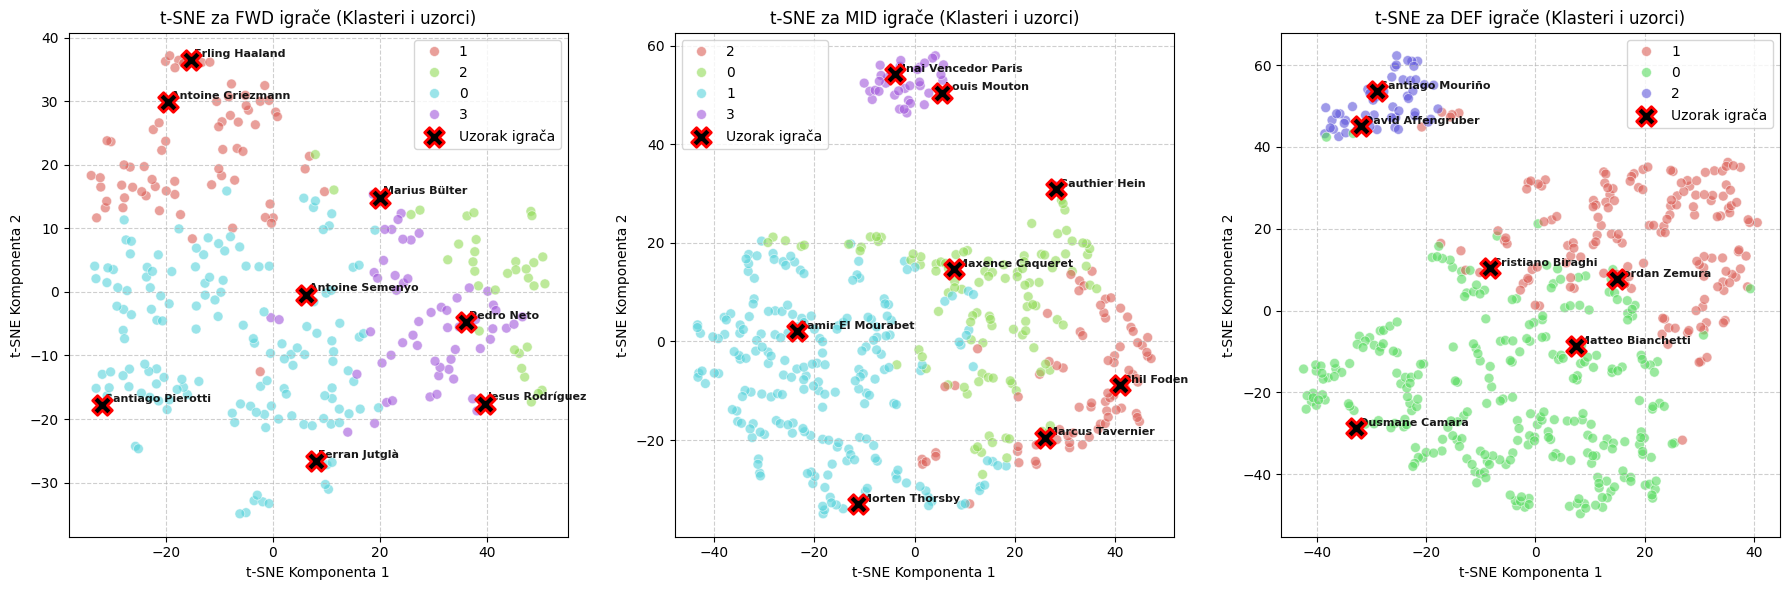

t-SNE raspršeni dijagrami generirani.


In [15]:
# ----------------------------
# 17. Vizualizacija t-SNE
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

print("Generiranje t-SNE raspršenih dijagrama za FWD, MID i DEF...")

tsne_pos_groups_to_plot = ['FWD', 'MID', 'DEF']

plt.figure(figsize=(18, 6))

for i, pos_group in enumerate(tsne_pos_groups_to_plot):
    if pos_group in position_data and 'tsne_2d' in position_data[pos_group] and 'df' in position_data[pos_group]:
        ax = plt.subplot(1, len(tsne_pos_groups_to_plot), i + 1)

        df_clustered = position_data[pos_group]['df']
        tsne_coords = position_data[pos_group]['tsne_2d']

        # Stvaranje privremenog DataFrame za crtanje
        plot_df = pd.DataFrame({
            'tsne-2d-jedan': tsne_coords[:, 0],
            'tsne-2d-dva': tsne_coords[:, 1],
            'Klaster': df_clustered['Cluster'].astype(str), # Pretvori u string za kategoričko bojanje
            'Igrač': df_clustered['Player'],
            'Klub': df_clustered['Squad']
        })

        # Nacrta sve igrače, obojene po klasteru
        sns.scatterplot(
            x="tsne-2d-jedan", y="tsne-2d-dva",
            hue="Klaster",
            palette=sns.color_palette("hls", df_clustered['Cluster'].nunique()),
            data=plot_df,
            legend="full",
            alpha=0.6,
            s=50, # veličina točaka
            ax=ax
        )

        # Istakne uzorkovane igrače
        highlight_players_list = sample_players_to_highlight.get(pos_group, [])
        if highlight_players_list:
            highlight_names = [p['Player'] for p in highlight_players_list]
            highlight_squads = [p['Squad'] for p in highlight_players_list]

            # Filtriranje plot_df da bi se dobile koordinate istaknutih igrača
            df_highlight = plot_df[plot_df['Igrač'].isin(highlight_names) & plot_df['Klub'].isin(highlight_squads)].copy()

            # Nacrta istaknute igrače s različitim markerom i većom veličinom
            sns.scatterplot(
                x="tsne-2d-jedan", y="tsne-2d-dva",
                data=df_highlight,
                marker='X', # Koristi 'X' za istaknute igrače
                s=200, # Veća veličina
                color='black', # Različita boja
                edgecolor='red', # Crveni obrub
                linewidth=2,
                label='Uzorak igrača',
                ax=ax,
                zorder=5 # Osigurava da su istaknuti igrači na vrhu
            )
            # Dodavanje bilješki za istaknute igrače
            for _, row in df_highlight.iterrows():
                ax.text(
                    row['tsne-2d-jedan'] + 0.5, row['tsne-2d-dva'] + 0.5,
                    f"{row['Igrač']}",
                    fontsize=8,
                    alpha=0.9,
                    color='black',
                    weight='bold'
                )

        ax.set_title(f't-SNE za {pos_group} igrače (Klasteri i uzorci)')
        ax.set_xlabel('t-SNE Komponenta 1')
        ax.set_ylabel('t-SNE Komponenta 2')
        ax.grid(True, linestyle='--', alpha=0.6)

    else:
        print(f"Upozorenje: Potrebni podaci za '{pos_group}' nisu pronađeni. Preskače se crtanje.")

plt.tight_layout()
plt.show()

print("t-SNE raspršeni dijagrami generirani.")

# Faza 3: Usporedna analiza metrika

U ovom dijelu sustavno uspoređujemo četiri metrike sličnosti (`cosine`, `euclidean`,
`dot_product`, `soft_cosine`) kroz nekoliko komplementarnih analiza:

- **A) Slaganje metoda** — koliko se metrike međusobno slažu (Jaccard@10 i Spearman).
- **B) Studije slučaja** — top-5 sličnih za izabrane igrače reprezentativnih profila.
- **C) Proxy ground-truth** — precision@5/@10 prema poziciji i K-Means klasteru.
- **D) Stabilnost** — otpornost top-lista na bootstrap i izbacivanje značajke.

Glavna os razlike među metrikama je **smjer profila** (kosinus, soft-kosinus → *stil* igre)
nasuprot **magnitudi** (euklid, skalarni produkt → *razina* doprinosa).

## A) Slaganje metoda

Mjerimo koliko se metrike međusobno slažu, na dvije razine:

- **Jaccard@10** — preklapanje skupova *top-10* najsličnijih igrača (fokus na vrh liste,
  ono što skaut zapravo gleda).
- **Spearman** — rang-korelacija *cijelog* poretka susjeda (fokus na ukupno slaganje).

Za svakog igrača računamo obje mjere za svaki par metrika, pa ih prosječimo preko svih
1243 igrača (sličnost se uvijek računa unutar pozicijske grupe). Rezultat su dvije
matrice 4×4 prikazane kao toplinske karte.

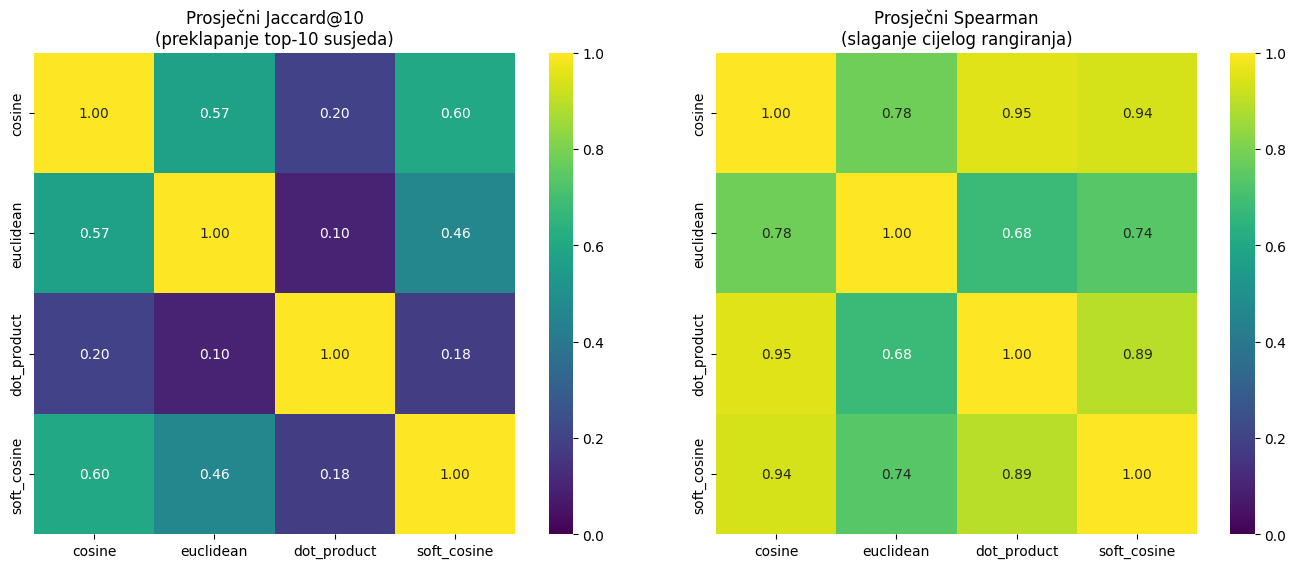

Jaccard@10 (prosjek po igraču):
             cosine  euclidean  dot_product  soft_cosine
cosine        1.000      0.569        0.197        0.601
euclidean     0.569      1.000        0.097        0.462
dot_product   0.197      0.097        1.000        0.177
soft_cosine   0.601      0.462        0.177        1.000

Spearman (prosjek po igraču):
             cosine  euclidean  dot_product  soft_cosine
cosine        1.000      0.781        0.950        0.937
euclidean     0.781      1.000        0.678        0.736
dot_product   0.950      0.678        1.000        0.891
soft_cosine   0.937      0.736        0.891        1.000


In [16]:
# ----------------------------
# 3A. Slaganje metoda: Jaccard@10 (vrh liste) i Spearman (cijelo rangiranje)
# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata

metric_names = list(METRICS)
K = 10


def _pair_score_matrix(X, metric, M=None):
    """N×N matrica sličnosti gdje je VEĆE = sličnije.
    (euklid se vraća kao NEGATIVNA udaljenost, da orijentacija bude ista za sve.)"""
    if metric == 'cosine':
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        return Xn @ Xn.T
    if metric == 'dot_product':
        return X @ X.T
    if metric == 'euclidean':
        sq = np.sum(X ** 2, axis=1)
        d2 = sq[:, None] + sq[None, :] - 2 * (X @ X.T)
        return -np.sqrt(np.clip(d2, 0, None))
    if metric == 'soft_cosine':
        G = X @ M @ X.T
        nrm = np.sqrt(np.clip(np.diag(G), 1e-12, None))
        return G / np.outer(nrm, nrm)
    raise ValueError(metric)


def _avg_rowwise_pearson(A, B):
    """Prosječni Pearson po retku; na rangovima je to Spearman."""
    A = A - A.mean(1, keepdims=True)
    B = B - B.mean(1, keepdims=True)
    num = (A * B).sum(1)
    den = np.sqrt((A ** 2).sum(1) * (B ** 2).sum(1)) + 1e-12
    return (num / den).mean()


jac_sum = np.zeros((4, 4))
spe_sum = np.zeros((4, 4))
n_total = 0

# Akumuliramo preko svih igrača svih grupa (sličnost se uvijek računa unutar grupe).
for pg, data in position_data.items():
    X, M = data['std_features'], data['M']
    n = len(X)
    S = {m: _pair_score_matrix(X, m, M) for m in metric_names}
    topk, ranks = {}, {}
    for m in metric_names:
        Sm = S[m].copy()
        np.fill_diagonal(Sm, -np.inf)                 # isključi samog igrača
        topk[m] = np.argsort(-Sm, axis=1)[:, :K]      # top-K susjedi
        R = np.empty((n, n - 1))
        for i in range(n):
            R[i] = rankdata(np.delete(S[m][i], i))    # rang ostalih (za Spearman)
        ranks[m] = R
    for a in range(4):
        for b in range(4):
            ma, mb = metric_names[a], metric_names[b]
            j = 0.0
            for i in range(n):
                A, B = set(topk[ma][i]), set(topk[mb][i])
                j += len(A & B) / len(A | B)
            jac_sum[a, b] += j
            spe_sum[a, b] += _avg_rowwise_pearson(ranks[ma], ranks[mb]) * n
    n_total += n

jaccard = pd.DataFrame(jac_sum / n_total, index=metric_names, columns=metric_names)
spearman = pd.DataFrame(spe_sum / n_total, index=metric_names, columns=metric_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, ax=axes[0])
axes[0].set_title("Prosječni Jaccard@10\n(preklapanje top-10 susjeda)")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, ax=axes[1])
axes[1].set_title("Prosječni Spearman\n(slaganje cijelog rangiranja)")
plt.tight_layout()
plt.show()

print("Jaccard@10 (prosjek po igraču):")
print(jaccard.round(3))
print()
print("Spearman (prosjek po igraču):")
print(spearman.round(3))

### Tumačenje 3A

Slaganje metrika ima **dvije osi**: **LOKALNO** (Jaccard@10 — vrh liste, najbliži susjedi)
i **GLOBALNO** (Spearman — cijeli poredak susjeda). Te dvije osi daju različitu sliku:

| Par metrika | Globalno (Spearman) | Lokalno (Jaccard@10) | Što to znači |
|---|---|---|---|
| `dot_product` ↔ `cosine` | **DA** (0.95) | **NE** (0.20) | isti grubi poredak, ali vrh preuzimaju volumni igrači |
| `euclidean` ↔ `cosine` | osrednje (0.78) | **DA** (0.57) | isti najbliži susjedi, ali repovi se razilaze |
| `cosine` ↔ `soft_cosine` | **DA** (0.94) | **DA** (0.60) | slični na OBJE skale (jedini takav par) |

**Mehanizam:** `dot_product = cosine × magnituda`. Množenje pozitivnim skalarom (normom
vektora) **čuva grubi poredak** pa je Spearman s kosinusom vrlo visok (0.95), ali **gura
visoko-volumne igrače na sam vrh** liste pa se Jaccard@10 ruši (0.20). Obrnuto, `euclidean`
mjeri udaljenost: za **najbliže** susjede udaljenost i kut se poklapaju (sličan top-10), no
u **repovima** se razilaze (niži Spearman).

**Zašto je za skauting Jaccard@10 važniji od Spearmana:** skaut u praksi gleda **vrh liste
preporuka**, ne cijeli rep. Visok Spearman uz nizak Jaccard (kao kod `dot_product`↔`cosine`)
znači da se metrike slažu "u sredini i dnu poretka, ali se **razilaze upravo na vrhu**" — a
vrh je jedino što se koristi. Zato se iz visokog Spearmana **ne smije** zaključiti da su
metrike praktički iste; mjerodavno je preklapanje na vrhu, gdje `dot_product` (količina)
jasno odudara od triju metrika stila, dok su `cosine` i `soft_cosine` najbliži par na obje skale.

## B) Studije slučaja

Promatramo četiri igrača namjerno odabrana po **različitim profilima**, tako da pokrivaju
obje osi razlike među metrikama:

| Igrač | Grupa | Profil | Dominantne značajke (z-score) |
|---|---|---|---|
| **Erling Haaland** | FWD | čisti strijelac (ekstremna magnituda) | G-PK ≈ npxG ≈ **+5.3**, ostalo ~0 |
| **Kevin De Bruyne** | MID | kreator (vođen kreacijom) | **xAG +1.51**, PrgP +1.77, golovi niski |
| **Achraf Hakimi** | DEF | ofenzivni bek (progresija) | **PrgR +3.80**, PrgP +1.71 |
| **Curtis Jones** | MID | box-to-box (čista progresija) | **PrgP +3.61**, PrgC +1.23, xAG −0.19 |

Za svakog igrača prikazujemo **top-5 najsličnijih po svakoj od četiri metrike** (jedan
stupac po metrici), pa se izravno vidi gdje se rangiranja razilaze.

In [17]:
# ----------------------------
# 3B-1. Tablice top-5 sličnih: jedan stupac po metrici, za svakog ciljanog igrača
# ----------------------------
from IPython.display import display

case_players = ["Haaland", "De Bruyne", "Hakimi", "Curtis Jones"]


def _resolve_target(player_name):
    """Vrati (redak, pozicijska_grupa) za prvog igrača koji odgovara imenu."""
    for pg, data in position_data.items():
        m = data['df'][data['df']['Player'].str.contains(player_name, case=False, na=False)]
        if len(m) > 0:
            return m.iloc[0], pg
    return None, None


def case_study_table(player_name, n=5):
    """Tablica top-n najsličnijih igrača — jedan STUPAC po metrici."""
    cols = {}
    for met in METRICS:
        res = find_similar_players(player_name, metric=met, n_similar=n, verbose=False)
        cols[met] = list(res['Player'])
    return pd.DataFrame(cols, index=[f"{i}." for i in range(1, n + 1)])


for p in case_players:
    info, pg = _resolve_target(p)
    print(f"\nCILJ: {info['Player']}  |  {info['Pos']} ({pg})  |  {info['Squad']}")
    display(case_study_table(p))


CILJ: Erling Haaland  |  FW (FWD)  |  Manchester City


,cosine,euclidean,dot_product,soft_cosine
1.,Robert Lewandowski,Robert Lewandowski,Harry Kane,Odsonne Édouard
2.,Esteban Lepaul,Ferrán Torres,Robert Lewandowski,Robert Lewandowski
3.,Donyell Malen,Harry Kane,Jonathan Burkardt,Esteban Lepaul
4.,Odsonne Édouard,Jonathan Burkardt,Christian Pulisic,Donyell Malen
5.,Ferrán Torres,Esteban Lepaul,Ferrán Torres,Ferrán Torres



CILJ: Kevin De Bruyne  |  MF (MID)  |  Napoli


,cosine,euclidean,dot_product,soft_cosine
1.,Charles De Ketelaere,Dominik Szoboszlai,Jeremy Doku,Lazar Samardzic
2.,Lazar Samardzic,Warren Zaïre-Emery,Charles De Ketelaere,Charles De Ketelaere
3.,Warren Zaïre-Emery,Eduardo Camavinga,Rayan Cherki,Lee Kang-in
4.,Dominik Szoboszlai,Kévin Danois,Martin Ødegaard,Alex Iwobi
5.,Eduardo Camavinga,Yeremi Pino,Pedri,Nicolò Barella



CILJ: Achraf Hakimi  |  DF (DEF)  |  Paris S-G


,cosine,euclidean,dot_product,soft_cosine
1.,Wesley,Wesley,Konrad Laimer,Wesley
2.,Milos Kerkez,Milos Kerkez,Samuel Amo-Ameyaw,Amad Diallo
3.,Michael Amir Murillo,Michael Amir Murillo,Nuno Mendes,Nuno Mendes
4.,Timothy Weah,Timothy Weah,Wesley,Samuel Amo-Ameyaw
5.,Alexis Saelemaekers,Rasmus Kristensen,Amad Diallo,Germán Valera



CILJ: Curtis Jones  |  MF (MID)  |  Liverpool


,cosine,euclidean,dot_product,soft_cosine
1.,Himad Abdelli,Himad Abdelli,Vitinha,Himad Abdelli
2.,Moi Gómez,Domingos André Ribeiro Almeida,Martin Ødegaard,Domingos André Ribeiro Almeida
3.,Domingos André Ribeiro Almeida,Moi Gómez,Pedri,Pablo Barrios
4.,Pablo Barrios,Nikola Moro,Pascal Groß,Fabián Ruiz Peña
5.,Warren Zaïre-Emery,Warren Zaïre-Emery,Aleksandar Pavlovic,Sergi Darder


In [18]:
# ----------------------------
# 3B-2. Ključni test: kreator (De Bruyne) vs samo-progresor (Curtis Jones)
# ----------------------------
# Oba veznjaka imaju visok PrgP (DBV +1.77, Jones +3.61), ali se bitno razlikuju u
# KREACIJI (xAG: DBV +1.51 vs Jones -0.19). Pitanje: koja metrika ih svrstava blizu
# (gleda samo zajedničku progresiju), a koja ih razdvaja (uvažava kreaciju)?

def cross_rank(target, other_substr):
    """Za svaku metriku vrati rang i score igrača `other_substr` na potpunoj
    listi sličnih igraču `target` (unutar njegove pozicijske grupe)."""
    row = {}
    for met in METRICS:
        res = find_similar_players(target, metric=met, n_similar=10**9, verbose=False)
        names = list(res['Player'])
        hit = [i for i, nm in enumerate(names) if other_substr in nm]
        row[met] = (f"{hit[0] + 1}. (score {res['Score'].iloc[hit[0]]:.3f})"
                    if hit else "—")
    return row

n_mid = len(position_data['MID']['df'])
cross = pd.DataFrame({
    f"Curtis Jones u susjedstvu De Bruynea (/{n_mid})": cross_rank("De Bruyne", "Curtis Jones"),
    f"De Bruyne u susjedstvu Curtisa Jonesa (/{n_mid})": cross_rank("Curtis Jones", "De Bruyne"),
}).T
print("Rang (i sličnost) ciljanog igrača na listi onog drugog:")
display(cross)

Rang (i sličnost) ciljanog igrača na listi onog drugog:


,cosine,euclidean,dot_product,soft_cosine
Curtis Jones u susjedstvu De Bruynea (/441),23. (score 0.704),119. (score 2.889),13. (score 7.612),108. (score 0.635)
De Bruyne u susjedstvu Curtisa Jonesa (/441),37. (score 0.704),31. (score 2.889),36. (score 7.612),55. (score 0.635)


In [19]:
# ----------------------------
# 3B-3. Razlaganje euklidske udaljenosti De Bruyne ↔ Curtis Jones po značajkama
# ----------------------------
# Provjeravamo ŠTO točno razdvaja ovaj par: koliko svaka značajka doprinosi kvadratu
# euklidske udaljenosti, (z_DBV - z_Jones)^2, i koliki je njezin udio u ukupnoj sumi.

def _zvec(name):
    d = position_data['MID']['df']
    row = d[d['Player'].str.contains(name, case=False, na=False)].iloc[0]
    return row[feature_cols].astype(float)

z_dbv = _zvec("De Bruyne")
z_jon = _zvec("Curtis Jones")
contrib = (z_dbv - z_jon) ** 2
decomp = pd.DataFrame({
    "z_DBV": z_dbv.round(2),
    "z_Jones": z_jon.round(2),
    "(razlika)^2": contrib.round(3),
    "udio_%": (100 * contrib / contrib.sum()).round(1),
}).sort_values("(razlika)^2", ascending=False)

print(f"Euklidska udaljenost = {np.sqrt(contrib.sum()):.3f}  |  "
      f"norma(DBV) = {np.linalg.norm(z_dbv):.2f}  |  norma(Jones) = {np.linalg.norm(z_jon):.2f}")
display(decomp)

Euklidska udaljenost = 2.889  |  norma(DBV) = 2.67  |  norma(Jones) = 4.06


,z_DBV,z_Jones,(razlika)^2,udio_%
PrgP_90,1.77,3.61,3.387,40.6
xAG_90,1.51,-0.19,2.864,34.3
G-PK_90,0.22,-0.76,0.955,11.4
npxG_90,0.15,-0.52,0.450,5.4
PrgR_90,0.51,-0.09,0.365,4.4
PrgC_90,0.82,1.23,0.165,2.0
CrdY_90,-0.20,-0.60,0.158,1.9
Ast_90,-0.76,-0.76,0.000,0.0
CrdR_90,-0.30,-0.30,0.000,0.0


### Tumačenje: De Bruyne ↔ Curtis Jones (kreacija *i* magnituda)

Oba veznjaka imaju visok `PrgP`, ali se razlikuju u `xAG` (+1.51 vs −0.19). Rang drugoga
na listi sličnih (od 441 veznjaka):

| | cosine | euclidean | dot_product | soft_cosine |
|---|---|---|---|---|
| Jones kod De Bruynea | 23. | 119. | **13.** | 108. |
| De Bruyne kod Jonesa | 37. | 31. | 36. | 55. |

**Što ih zapravo razdvaja (razlaganje euklidske udaljenosti, prethodna ćelija):** najveći
doprinos daje `PrgP` (~41 %), pa tek onda `xAG` (~34 %); te dvije osi nose ~75 % udaljenosti.
Razdvajanje dakle **nije samo "kreacija"** — gotovo jednako doprinosi to što je Jones ukupno
*veći i ekstremniji* progresijski vektor (norma 4.06 vs 2.67; progresira čak i više od
De Bruynea). Kreacija (`xAG`) je drugi, ne jedini, izvor razlike.

**Zašto je tablica asimetrična:** Jones je ekstreman vektor u rijetkom dijelu prostora. Iz
gustog susjedstva De Bruynea on je outlier (119.), dok je iz Jonesovog rijetkog susjedstva
De Bruyne tek jedan od mnogih umjerenih veznjaka (31.). Asimetrija je posljedica
**magnitude/gustoće**, što dodatno potvrđuje da odvajanje nije čisto stvar kreacije.

**Kako metrike reagiraju:**
- `cosine` ih drži blizu — smjer profila im se preklapa (oba progresijski nagnuti).
- `dot_product` ih drži NAJBLIže. To **nije pogreška**: skalarni produkt odgovara na *drugo
  pitanje* — "slične akcije u sličnoj **količini**". Za skauting (npr. traženje jednako
  *produktivne* zamjene, a ne nužno istog stila) to je legitiman kriterij, samo ne mjeri stil.
- `euclidean` i `soft_cosine` ih razdvajaju — osjetljivi su na cijeli profil, pa hvataju i
  razliku u volumenu progresije i u kreaciji.

**Zaključak:** par De Bruyne ↔ Jones pokazuje da metrike mjere *različita pitanja* (smjer/stil
nasuprot količini/magnitudi), ali **nije čist test "samo kreacije"**: njihovo odvajanje
kombinira razliku u kreaciji (`xAG`, ~34 %) i u ukupnoj magnitudi progresijskog profila
(`PrgP`, ~41 %).

## C) Proxy ground-truth: precision@5 i precision@10

Budući da ne postoji "točan odgovor" tko je kome sličan, koristimo dva **proxy** kriterija:

1. **Pozicija (pooled).** Sličnost računamo nad **svim** igračima (bez ograničenja na grupu);
   mjerimo udio top-k susjeda koji dijele istu poziciju (`PosGroup`). *(Unutar pozicijske grupe
   bi taj udio bio trivijalno 1.0.)*
2. **Klaster (unutar grupe).** Udio top-k susjeda u istom klasteru kao ciljani igrač; klaster
   služi kao gruba "oznaka stila" unutar pozicije.

**Kontrola tautologije:** nijedna klaster-podjela nije neutralna — svaka nastaje *nekom*
metrikom, pa ta metrika ima "domaći teren" na podjeli izvedenoj njome (npr. K-Means koristi
euklidsku udaljenost). Zato klaster-proxy računamo na **dvije** podjele s istim brojem klastera:
**K-Means** (euklidska) i **spektralna na kosinusnoj sličnosti** (ne-euklidska). Zaključak o
kvaliteti metrike smije se izvući samo iz onoga što vrijedi na **obje** podjele.

Precision@k po metrici (pos = pooled pozicija; KMeans = euklidska podjela; spektral = kosinusna podjela):
             pos_pos@5  pos_pos@10  KMeans_@5  KMeans_@10  spektral_@5  spektral_@10
metrika                                                                             
cosine           0.613       0.604      0.845       0.829        0.846         0.822
euclidean        0.615       0.597      0.875       0.861        0.827         0.799
dot_product      0.566       0.569      0.705       0.709        0.707         0.712
soft_cosine      0.601       0.597      0.860       0.848        0.869         0.846

Random baseline -> pozicija: 0.345 | K-Means klaster: 0.372 | spektral klaster: 0.302


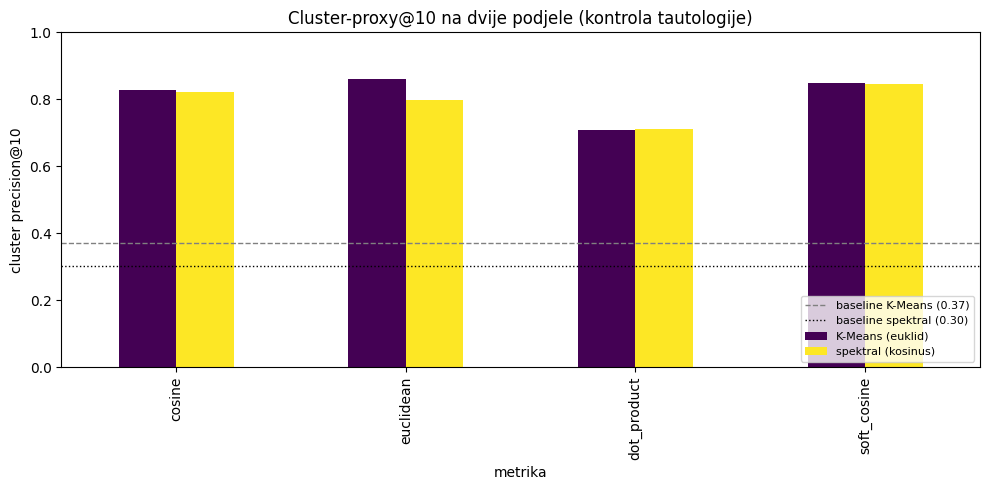

In [20]:
# ----------------------------
# 3C. Proxy ground-truth: precision@5 i precision@10
# ----------------------------
from sklearn.cluster import SpectralClustering
from sklearn.metrics.pairwise import cosine_similarity


def _precision_at_k(S, labels, ks=(5, 10)):
    """Udio top-k susjeda (bez sebe) koji dijele oznaku `labels` s ciljnim igračem."""
    Sm = S.copy()
    np.fill_diagonal(Sm, -np.inf)
    order = np.argsort(-Sm, axis=1)
    return {k: (labels[order[:, :k]] == labels[:, None]).mean() for k in ks}


# --- (1) Pozicija: POOLED preko svih igrača (bez ograničenja na grupu) ---
X_all = df_scaled[feature_cols].values
pos_labels = df_scaled['PosGroup'].values
M_all = np.nan_to_num(np.corrcoef(X_all, rowvar=False), nan=0.0)   # globalni M za soft_cosine
pos_baseline = float((df_scaled['PosGroup'].value_counts(normalize=True) ** 2).sum())

pos_rows = []
for m in metric_names:
    pk = _precision_at_k(_pair_score_matrix(X_all, m, M_all), pos_labels)
    pos_rows.append({'metrika': m, 'pos@5': pk[5], 'pos@10': pk[10]})
pos_prec = pd.DataFrame(pos_rows).set_index('metrika')

# --- (2) Dvije klaster-podjele (kontrola tautologije) ---
#   'Cluster'     = K-MEANS (euklidski; izračunat u ranijoj ćeliji)
#   'Cluster_cos' = SPEKTRALNO na KOSINUSNOJ sličnosti (ne-euklidski), iste veličine
n_clusters_map = {'FWD': 4, 'MID': 4, 'DEF': 3}
for pg, data in position_data.items():
    aff = (cosine_similarity(data['std_features']) + 1.0) / 2.0    # [-1, 1] -> [0, 1]
    data['df']['Cluster_cos'] = SpectralClustering(
        n_clusters=n_clusters_map[pg], affinity='precomputed',
        random_state=42, assign_labels='kmeans').fit_predict(aff)


def _cluster_precision(label_col):
    """Prosječni precision@k da susjed dijeli oznaku `label_col` s ciljem (unutar grupe)."""
    acc = {m: {5: 0.0, 10: 0.0} for m in metric_names}
    base, n_tot = 0.0, 0
    for pg, data in position_data.items():
        X, M = data['std_features'], data['M']
        lab = data['df'][label_col].values
        n = len(X)
        base += float((data['df'][label_col].value_counts(normalize=True) ** 2).sum()) * n
        for m in metric_names:
            pk = _precision_at_k(_pair_score_matrix(X, m, M), lab)
            acc[m][5] += pk[5] * n
            acc[m][10] += pk[10] * n
        n_tot += n
    out = pd.DataFrame(
        [{'metrika': m, '@5': acc[m][5] / n_tot, '@10': acc[m][10] / n_tot}
         for m in metric_names]).set_index('metrika')
    return out, base / n_tot


km_prec, km_base = _cluster_precision('Cluster')        # euklidska podjela (K-Means)
sp_prec, sp_base = _cluster_precision('Cluster_cos')    # kosinusna podjela (spektralna)

# --- prikaz ---
combo = pd.concat([pos_prec.add_prefix('pos_'),
                   km_prec.add_prefix('KMeans_'),
                   sp_prec.add_prefix('spektral_')], axis=1)
print("Precision@k po metrici "
      "(pos = pooled pozicija; KMeans = euklidska podjela; spektral = kosinusna podjela):")
print(combo.round(3).to_string())
print()
print(f"Random baseline -> pozicija: {pos_baseline:.3f} | "
      f"K-Means klaster: {km_base:.3f} | spektral klaster: {sp_base:.3f}")

# usporedni bar-plot cluster-proxy@10: K-Means (euklid) vs spektral (kosinus)
cmp10 = pd.DataFrame({'K-Means (euklid)': km_prec['@10'],
                      'spektral (kosinus)': sp_prec['@10']})
ax = cmp10.plot(kind='bar', figsize=(10, 5), colormap='viridis')
ax.axhline(km_base, color='gray', ls='--', lw=1, label=f'baseline K-Means ({km_base:.2f})')
ax.axhline(sp_base, color='black', ls=':', lw=1, label=f'baseline spektral ({sp_base:.2f})')
ax.set_ylabel('cluster precision@10')
ax.set_ylim(0, 1)
ax.set_title('Cluster-proxy@10 na dvije podjele (kontrola tautologije)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Tumačenje 3C

**Pozicija (pooled):** sve metrike ~0.57–0.62 (iznad random 0.35), ali umjereno — ~40 %
najsličnijih susjeda je iz druge pozicijske grupe. Ofenzivni profil ne razdvaja čisto pozicije
(ofenzivni bek "izgleda" kao krilo, box-to-box veznjak kao napadač); izravno povezano s
**limitacijom** podataka (nema obrambenih/posjedovnih značajki). I ovdje je `dot_product`
najslabiji (0.57).

**Klaster — dvije podjele (cluster precision@10):**

| Metrika | K-Means (euklid) | Spektral (kosinus) | Δ |
|---|---|---|---|
| `cosine` | 0.829 | 0.822 | −0.01 |
| `euclidean` | **0.861** | 0.799 | **−0.06** |
| `dot_product` | 0.709 | 0.712 | +0.00 |
| `soft_cosine` | 0.848 | **0.846** | −0.00 |
| *random* | *0.372* | *0.302* | |

**Glavni nalaz (zbog čega je kontrola i napravljena):**

- **Prednost `euclideana` JE artefakt.** Vodeći je na K-Means podjeli (0.861), ali na
  ne-euklidskoj (spektralnoj, kosinusnoj) padne na **3. mjesto** (0.799; Δ −0.06). Vodi, dakle,
  samo na podjeli koju je K-Means izveo euklidski — to mu je "domaći teren".
- **`cosine` i `soft_cosine` su STABILNI na obje podjele** (Δ ≈ 0; `soft_cosine` je čak najviši
  na kosinusnoj). Njihova kvaliteta **ne ovisi** o tome kojom je metrikom podjela napravljena —
  to je čvrst nalaz.
- **`dot_product` je najslabiji na OBJE podjele** (~0.71), i to stabilno. Njegova slabija
  uspješnost stoga **nije** artefakt, nego posljedica toga što mjeri *količinu*, a ne *stil*.

**Zaključak:** budući da nijedna podjela nije neutralna, vrijede samo zaključci koji se drže na
obje. Robusno: `dot_product` (količina) zaostaje, dok su `cosine` i `soft_cosine` solidni i
**neovisni o podjeli** — uz ogradu da su `cosine` i `soft_cosine` na obje podjele praktički **identični** (Δ unutar šuma), pa iz 3C **ne** tvrdimo "soft > cosine", nego samo da su tri stilske metrike robusne, a `dot_product` zaostaje. Raniji dojam da je `euclidean` "najbolji" bio je artefakt euklidske
prirode K-Meansa — u neutralnijoj usporedbi `euclidean` nije bolji od kosinusnih metrika.

## D) Stabilnost

Mjerimo koliko su top-liste **otporne na perturbacije**, kroz dvije *odvojene* analize
(ne prosječujemo ih zajedno):

- **A) Stabilnost na prostor značajki** *(primarno — imamo samo 9 značajki)*: izbacimo jednu
  značajku (leave-one-feature-out, 9 ponavljanja), ponovno izračunamo top-10 i mjerimo
  Jaccard@10 spram punog prostora.
- **B) Stabilnost na uzorak**: značajkama dodamo mali Gaussov šum (σ = 0.1 na standardiziranim
  vrijednostima, 20 ponavljanja) i mjerimo Jaccard@10 spram neperturbiranog. *(Šum je čišći od
  resamplea redaka, koji bi mehanički mijenjao skup kandidata.)*

Veći Jaccard = stabilnija metrika. **Stabilnost se čita zajedno s 3C** (vidi tumačenje).

Stabilnost top-10 (Jaccard@10 vs neperturbirano; veće = stabilnije)
A: leave-one-feature-out (9 ponavljanja)  |  B: Gaussov šum σ=0.1 (20 ponavljanja)

             A: izbacena znacajka  B: Gaussov sum
cosine                      0.632           0.677
euclidean                   0.637           0.674
dot_product                 0.728           0.763
soft_cosine                 0.595           0.675


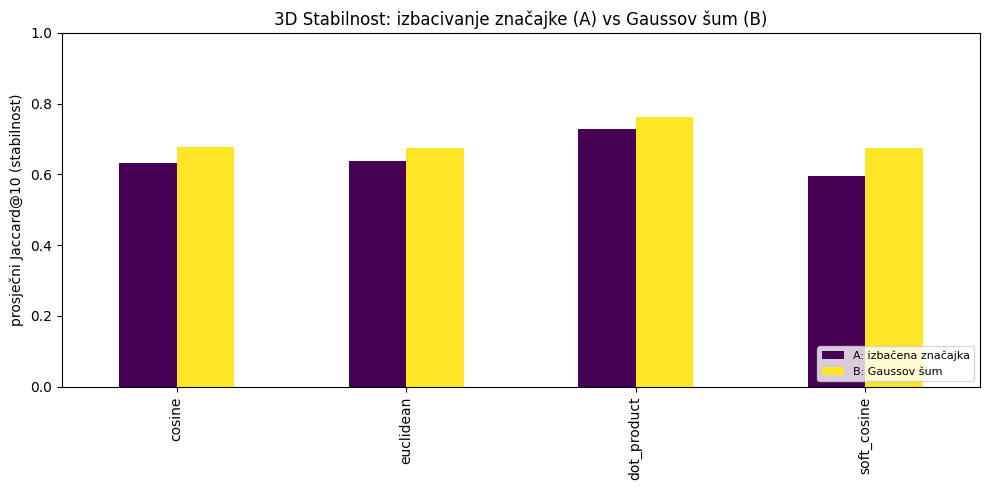

In [21]:
# ----------------------------
# 3D. Stabilnost top-lista (dvije odvojene analize)
# ----------------------------

def _topk_sets(X, metric, k=10):
    """Top-k susjedi (indeksi, bez sebe) za svakog igrača, na matrici X i zadanoj metrici."""
    M = np.nan_to_num(np.corrcoef(X, rowvar=False), nan=0.0) if metric == 'soft_cosine' else None
    S = _pair_score_matrix(X, metric, M)
    np.fill_diagonal(S, -np.inf)
    return np.argsort(-S, axis=1)[:, :k]


def _mean_jaccard(base_top, new_top):
    """Prosječni Jaccard@k između dvije liste top-k skupova (po igraču)."""
    tot = 0.0
    for i in range(len(base_top)):
        A, B = set(base_top[i]), set(new_top[i])
        tot += len(A & B) / len(A | B)
    return tot / len(base_top)


def _weighted_mean(pairs):
    num = sum(v * w for v, w in pairs)
    den = sum(w for _, w in pairs)
    return num / den


K = 10
rng = np.random.default_rng(42)

# Baseline top-K na PUNOM prostoru, po grupi i metrici.
base_top = {pg: {m: _topk_sets(data['std_features'], m, K) for m in metric_names}
            for pg, data in position_data.items()}

# --- A) Stabilnost na PROSTOR ZNAČAJKI: leave-one-feature-out (9 ponavljanja) ---
A_acc = {m: [] for m in metric_names}
for pg, data in position_data.items():
    X = data['std_features']
    w = len(X)
    for j in range(X.shape[1]):
        Xs = np.delete(X, j, axis=1)
        for m in metric_names:
            A_acc[m].append((_mean_jaccard(base_top[pg][m], _topk_sets(Xs, m, K)), w))

# --- B) Stabilnost na UZORAK: Gaussov šum (sigma=0.1, 20 ponavljanja) ---
SIGMA, REPS = 0.1, 20
B_acc = {m: [] for m in metric_names}
for pg, data in position_data.items():
    X = data['std_features']
    w = len(X)
    for _ in range(REPS):
        Xp = X + rng.normal(0.0, SIGMA, X.shape)
        for m in metric_names:
            B_acc[m].append((_mean_jaccard(base_top[pg][m], _topk_sets(Xp, m, K)), w))

stab = pd.DataFrame({
    'A: izbacena znacajka': {m: _weighted_mean(A_acc[m]) for m in metric_names},
    'B: Gaussov sum':       {m: _weighted_mean(B_acc[m]) for m in metric_names},
})
print("Stabilnost top-10 (Jaccard@10 vs neperturbirano; veće = stabilnije)")
print(f"A: leave-one-feature-out (9 ponavljanja)  |  B: Gaussov šum σ={SIGMA} ({REPS} ponavljanja)")
print()
print(stab.round(3).to_string())

ax = stab.plot(kind='bar', figsize=(10, 5), colormap='viridis')
ax.set_ylabel('prosječni Jaccard@10 (stabilnost)')
ax.set_ylim(0, 1)
ax.set_title('3D Stabilnost: izbacivanje značajke (A) vs Gaussov šum (B)')
ax.legend(['A: izbačena značajka', 'B: Gaussov šum'], loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Tumačenje 3D

| Metrika | A: izbačena značajka | B: Gaussov šum | (podsjetnik 3C) |
|---|---|---|---|
| `cosine` | 0.63 | 0.68 | dobar, robustan na obje podjele |
| `euclidean` | 0.64 | 0.67 | dobar samo na euklidskoj podjeli |
| `dot_product` | **0.73** | **0.76** | najslabiji |
| `soft_cosine` | 0.60 | 0.68 | dobar, robustan na obje podjele |

- **Analiza A (prostor značajki) nam je primarna.** Uz samo 9 značajki, izbacivanje jedne mijenja
  ~30–40 % top-10 (Jaccard 0.60–0.73) — to je samo po sebi **limitacija** maloga prostora.
- **`dot_product` je najstabilniji** (0.73 / 0.76): dominira ga ukupna magnituda, otporna na
  izbacivanje jedne značajke i mali šum (visoko-volumni igrači ostaju na vrhu).
- **`soft_cosine` — TRADE-OFF, ne mana.** Tek je neznatno najniži na izbacivanju značajke
  (0.595 vs 0.632 za `cosine` — razlika 0.037). Razlog je *sadržajan*: matrica **M** se
  prekalibrira kad značajka nestane, a upravo je to svrha soft-kosinusa (uvažava odnose među
  značajkama). Soft tako kupuje **bolju diskriminaciju** (usp. 3B: razdvajanje De Bruyne ↔ Jones)
  po cijeni **nešto veće osjetljivosti na izbor značajki** — kompromis, ne nedostatak.
- `cosine` i `euclidean` su u sredini (~0.63–0.68).

**KLJUČNO — stabilnost se čita ZAJEDNO s 3C, nije sama po sebi vrlina.** Tražimo metriku koja je
istodobno **dobra** (3C) i **stabilna** (3D):

- `dot_product` je najstabilniji, ali u 3C najslabiji (mjeri *količinu*, ne *stil*) →
  **stabilnost ga ne spašava**; on je *stabilno osrednji*.
- `soft_cosine` plaća malu cijenu stabilnosti za bolju diskriminaciju (gore).
- `cosine` je **najuravnoteženiji od tri bliske stilske metrike** — solidan u 3C i razumno stabilan
  u 3D. No razlike između `cosine`, `euclidean` i `soft_cosine` male su posvuda: **nemamo jasnog
  pobjednika, nego nijanse**; ne tvrdimo da je ijedna "najbolja metrika".

# Zaključak: usporedba metrika sličnosti

## Sažetak po analitičkom sloju

**3A — Slaganje metoda (inverzija Jaccard/Spearman).** Metrike se slažu drukčije na *vrhu* liste
nego u *cijelom* poretku: na top-10 (Jaccard@10) tri "stilske" metrike (`cosine`, `euclidean`,
`soft_cosine`) čine klaster (0.46–0.60), dok je `dot_product` autsajder (0.10–0.20); na cijelom
poretku (Spearman) `dot_product` je pak vrlo blizak kosinusu (0.95). Inverzija slijedi iz
`dot_product = cosine × magnituda`: množenje pozitivnom normom čuva grubi poredak, ali volumne
igrače gura na sam vrh.

**3B — Studije slučaja (stil vs količina).** Za sve mete (Haaland, De Bruyne, Hakimi, Curtis Jones)
tri stilske metrike daju srodne liste, dok `dot_product` dosljedno izbacuje visoko-volumne igrače
(Kane, Doku, Laimer, Vitinha). Par De Bruyne ↔ Curtis Jones (isti volumen progresije, različita
kreacija) razdvajaju `euclidean`/`soft_cosine`, a `dot_product`/`cosine` ih zbližavaju; razlaganje
pokazuje da odvajanje kombinira razliku u kreaciji (`xAG`, 34 %) i u magnitudi progresije
(`PrgP`, 41 %) — dakle nije čist test "samo kreacije".

**3C — Proxy ground-truth (robusnost na dvije podjele).** Sve metrike rekonstruiraju poziciju
iznad slučaja (~0.60 vs 0.35), ali umjereno (~40 % susjeda dolazi iz druge pozicije — posljedica
čisto ofenzivnog prostora). Na klaster-proxyju prividna prednost `euclideana` pokazala se kao
**artefakt**: vodi na euklidskoj (K-Means) podjeli (0.86), ali pada na 3. mjesto na ne-euklidskoj
(spektralnoj, kosinusnoj) podjeli (0.80). `cosine` i `soft_cosine` ostaju stabilni na obje, a
`dot_product` je najslabiji na obje.

**3D — Stabilnost (dot-paradoks).** `dot_product` je najotporniji na izbacivanje značajke i
Gaussov šum (0.73 / 0.76); `soft_cosine` plaća malu cijenu stabilnosti (0.60 na izbacivanju
značajke) za bolju diskriminaciju jer se matrica **M** prekalibrira; `cosine`/`euclidean` su u
sredini (~0.63–0.68).

## Poanta: paradoks `dot_product`-a

`dot_product` je istodobno **najstabilniji** (3D) i **najslabiji** po proxy-kvaliteti (3C), te
autsajder na vrhu liste (3A/3B). To pokazuje da **stabilnost nije vrlina sama po sebi**: on
stabilno vraća volumenom vođene susjede. No to nije pogreška — `dot_product` jednostavno odgovara
na **drugo pitanje**: "slične akcije u sličnoj **količini**", a ne "sličan stil". Za pojedine
skautske namjene (npr. traženje jednako *produktivne* zamjene) to je legitiman kriterij.

## Glavni zaključak

Na **interpretabilnom, standardiziranom prostoru** od 9 per-90 značajki sve četiri metrike daju
koristan signal (sve nadmašuju slučajni baseline). Tri "stilske" metrike (`cosine`, `euclidean`,
`soft_cosine`) ponašaju se vrlo slično: `cosine` je najuravnoteženiji, `soft_cosine` nudi nešto
bolju diskriminaciju uz veću osjetljivost na izbor značajki, a `euclidean` se na vrhu liste ponaša slično kosinusu, no njegova prividna prednost u proxy-mjeri pokazala se ovisnom o euklidskoj prirodi K-Meansa. Razlike među njima su **nijansa i stvar konteksta, ne
dramatične**; jedina jasna i robusna razlika jest da `dot_product` mjeri drugu dimenziju
(količinu). Drugim riječima, u ovakvom setupu izbor metrike najviše utječe na **vrh liste
preporuka**, a ne na grubi poredak.

## Veza na Steck et al. (kritika "proizvoljnog kosinusa")

Steck i sur. pokazuju da kosinusna sličnost može biti **proizvoljna** za **naučene embeddinge**
(npr. iz regulariziranih linearnih / matrix-factorization modela): regularizacija ostavlja modelu
slobodu reskaliranja latentnih dimenzija, pa kosinus nije jednoznačno određen i može postati
besmislen. **Ključna razlika u našem setupu:** koristimo **ručno odabrane, standardizirane
značajke** s fiksnim, interpretabilnim osima — nema slobode reskaliranja koja izaziva tu
patologiju. Naši rezultati to potvrđuju empirijski: kosinus (i srodne metrike) ponašaju se
**konzistentno i smisleno**, bez znakova proizvoljnosti. **Doprinos ovog rada** stoga nije
prepričavanje kritike, nego **empirijska provjera dokle ona seže**: pokazujemo da se izvan režima
naučenih, regulariziranih embeddinga — u fiksnom prostoru značajki — kritika "proizvoljnog
kosinusa" **ne manifestira dramatično**, te razgraničavamo gdje odabir metrike doista jest bitan
(vrh liste; stil naspram količine) od onoga gdje nije (grubi poredak). Ovaj nalaz ne proturječi Stecku i sur., nego razgraničava režim u kojem njihova kritika vrijedi — naučeni, regularizirani embeddinzi — od režima fiksnih interpretabilnih značajki, gdje se ne manifestira; oba mogu biti istodobno točna.

## Ograničenja

Skup je **ofenzivno orijentiran** (nema obrambenih/posjedovnih značajki), pa su golmani isključeni,
a sličnost među braničima slabije izražena. Prostor ima samo **9 značajki**, zbog čega izbacivanje
jedne osjetno mijenja liste (3D). Podaci pokrivaju **polusezonu 2025/26** i top-5 liga; proxy
ground-truth je posredan (pozicija i klaster), bez stvarne "zlatne" oznake sličnosti. Napokon, neki parametri analize donekle su proizvoljni (σ = 0.1 za Gaussov šum u 3D; broj klastera FWD 4 / MID 4 / DEF 3), pa bi se rezultati mogli blago promijeniti pod drugim vrijednostima.

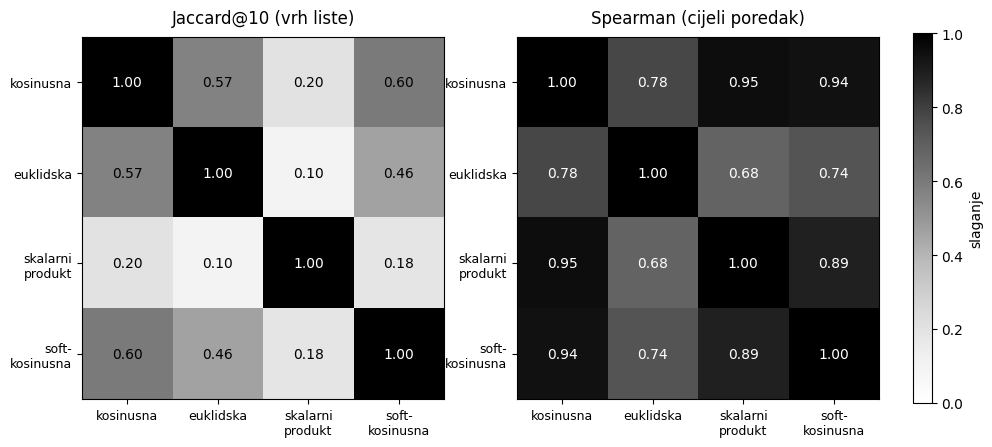

In [22]:
import numpy as np
import matplotlib.pyplot as plt

metode = ["kosinusna", "euklidska", "skalarni\nprodukt", "soft-\nkosinusna"]

# Jaccard@10 (preklapanje top-10), simetrična matrica, dijagonala = 1
jaccard = np.array([
    [1.00, 0.57, 0.20, 0.60],
    [0.57, 1.00, 0.10, 0.46],
    [0.20, 0.10, 1.00, 0.18],
    [0.60, 0.46, 0.18, 1.00],
])

# Spearman (cijeli poredak), simetrična matrica, dijagonala = 1
spearman = np.array([
    [1.00, 0.78, 0.95, 0.94],
    [0.78, 1.00, 0.68, 0.74],
    [0.95, 0.68, 1.00, 0.89],
    [0.94, 0.74, 0.89, 1.00],
])

def crtaj_heatmap(ax, M, naslov):
    im = ax.imshow(M, cmap="Greys", vmin=0, vmax=1, aspect="equal")
    ax.set_xticks(range(len(metode)))
    ax.set_yticks(range(len(metode)))
    ax.set_xticklabels(metode, fontsize=9)
    ax.set_yticklabels(metode, fontsize=9)
    ax.set_title(naslov, fontsize=12, pad=10)
    # brojevi u ćelijama (bijeli na tamnom, crni na svijetlom)
    for i in range(len(metode)):
        for j in range(len(metode)):
            boja = "white" if M[i, j] > 0.6 else "black"
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color=boja, fontsize=10)
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
crtaj_heatmap(ax1, jaccard, "Jaccard@10 (vrh liste)")
im = crtaj_heatmap(ax2, spearman, "Spearman (cijeli poredak)")

# zajednička skala boja desno
fig.colorbar(im, ax=[ax1, ax2], fraction=0.025, pad=0.04, label="slaganje")

plt.savefig("slaganje_metoda.pdf", bbox_inches="tight")
plt.savefig("slaganje_metoda.png", dpi=300, bbox_inches="tight")
plt.show()